In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

First 5 Rows
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape
(20640, 9)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float

Slope (Coefficient): 0.41933849393812705
Intercept: 0.4445972916907881

Mean Absolute Error: 0.629908653009376
Mean Squared Error: 0.7091157771765548
Root Mean Squared Error: 0.8420901241414454
R2 Score: 0.45885918903846656


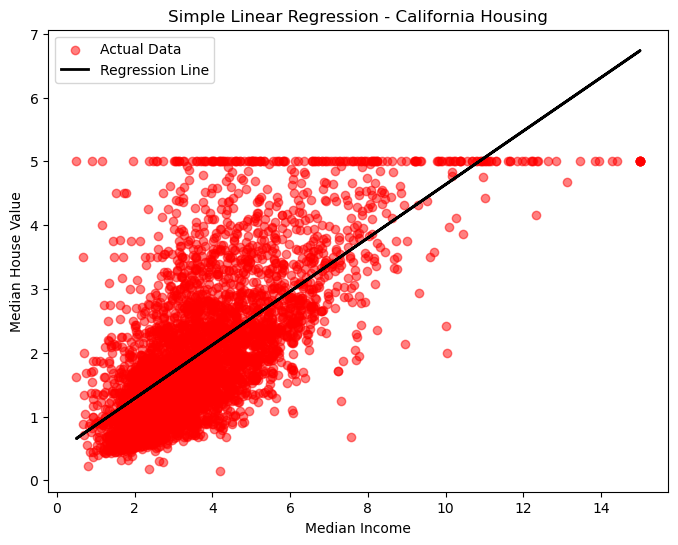

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------
# STEP 1: Load California Housing Dataset
# ---------------------------------------------------
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# ---------------------------------------------------
# STEP 2: Select one feature (Median Income)
# ---------------------------------------------------
X = df[['MedInc']]      # Independent variable
y = df['MedHouseVal']   # Target variable

# ---------------------------------------------------
# STEP 3: Split dataset
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------
# STEP 4: Create and Train Model
# ---------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------
# STEP 5: Prediction
# ---------------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------------
# STEP 6: Evaluation
# ---------------------------------------------------
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nMean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:",
      np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# ---------------------------------------------------
# STEP 7: Plot Regression Line
# ---------------------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='black', linewidth=2,
         label='Regression Line')

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression - California Housing")
plt.legend()
plt.show()